# Quant Surveillance System
A 5-layer system simulating insider behavior and detecting anomalies using both statistical and explainable models.

In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Layer 1: Simulate Enhanced Trade Data
np.random.seed(42)
random.seed(42)

trader_ids = [f"T{str(i).zfill(3)}" for i in range(1, 21)]
stocks = ['ABC', 'XYZ', 'LMN']
sides = ['buy', 'sell']
start_time = datetime.strptime("2025-04-01 09:30:00", "%Y-%m-%d %H:%M:%S")

def generate_trades_enhanced(n=1000, insider_ids=None):
    data = []
    for _ in range(n):
        trader = random.choice(trader_ids)
        stock = random.choice(stocks)
        side = random.choice(sides)
        quantity = int(np.random.exponential(scale=200)) + 10
        base_price = 100 + stocks.index(stock)*10
        price = round(np.random.normal(loc=base_price, scale=1), 2)
        time_offset = timedelta(seconds=random.randint(0, 3600))
        timestamp = start_time + time_offset
        data.append([timestamp, trader, stock, side, quantity, price])
    
    if insider_ids:
        for _ in range(20):
            trader = random.choice(insider_ids)
            stock = 'ABC'
            side = 'buy'
            quantity = random.randint(1000, 3000)
            price = round(np.random.normal(loc=105, scale=0.5), 2)
            time_offset = timedelta(seconds=random.randint(3540, 3599))
            timestamp = start_time + time_offset
            data.append([timestamp, trader, stock, side, quantity, price])

        for trader in insider_ids:
            base_time = start_time + timedelta(seconds=3200)
            for i in range(5):
                stock = 'ABC'
                side = 'buy'
                quantity = 100 + i * 50
                price = round(np.random.normal(loc=103 + i*0.2, scale=0.2), 2)
                timestamp = base_time + timedelta(seconds=i*30)
                data.append([timestamp, trader, stock, side, quantity, price])
    
    return pd.DataFrame(data, columns=['timestamp', 'trader_id', 'stock', 'side', 'quantity', 'price'])

insider_traders = ['T002', 'T005']
df = generate_trades_enhanced(n=1000, insider_ids=insider_traders)

In [2]:
# Layer 2: Feature Engineering
df['timestamp_numeric'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds()
df['side_encoded'] = df['side'].map({'buy': 1, 'sell': 0})

features = ['timestamp_numeric', 'quantity', 'price', 'side_encoded']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
# Layer 3: Isolation Forest - Anomaly Detection
iso_model = IsolationForest(n_estimators=100, contamination=0.025, random_state=42)
df['anomaly_score'] = iso_model.fit_predict(X_scaled)
df['is_anomaly'] = df['anomaly_score'] == -1

In [7]:
# Layer 4: Decision Tree Explanation
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X, df['is_anomaly'])
df['tree_pred'] = tree_model.predict(X)

In [9]:
# Update flag_reason with full logic
conditions = [
    (df['is_anomaly']) & (df['tree_pred'] == 1),
    (df['is_anomaly']) & (df['tree_pred'] == 0),
    (~df['is_anomaly']) & (df['tree_pred'] == 1),
    (~df['is_anomaly']) & (df['tree_pred'] == 0)
]
choices = [
    'Anomaly confirmed by both IF and Tree',
    'Anomaly detected by Isolation Forest only',
    'Potential anomaly (tree override)',
    'Normal'
]
df['flag_reason'] = np.select(conditions, choices, default='Normal')

# Final output of flagged trades
df_flagged = df[df['flag_reason'] != 'Normal']
df_flagged.head()

,timestamp,trader_id,stock,side,quantity,price,timestamp_numeric,side_encoded,anomaly_score,is_anomaly,tree_pred,flag_reason
54,2025-04-01 09:32:08,T002,ABC,buy,350,97.34,122.0,1,-1,True,True,Anomaly confirmed by both IF and Tree
166,2025-04-01 09:42:24,T014,ABC,sell,941,98.21,738.0,0,-1,True,True,Anomaly confirmed by both IF and Tree
190,2025-04-01 10:28:08,T019,XYZ,sell,863,109.34,3482.0,0,-1,True,False,Anomaly detected by Isolation Forest only
201,2025-04-01 09:50:54,T013,LMN,buy,1001,120.98,1248.0,1,-1,True,False,Anomaly detected by Isolation Forest only
361,2025-04-01 10:15:44,T018,LMN,sell,1163,119.84,2738.0,0,-1,True,True,Anomaly confirmed by both IF and Tree


## Layer 6 – LSTM-Based Temporal Pattern Detection
Train an LSTM to classify traders based on their last 10 trades.

In [12]:
# Prepare LSTM Input: 10-trade sequences per trader
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.optimizers import Adam

# Convert side/stock encoding
df['side_encoded'] = df['side'].map({'buy': 1, 'sell': 0})
df['stock_encoded'] = df['stock'].map({'ABC': 0, 'XYZ': 1, 'LMN': 2})
df_sorted = df.sort_values(by=['trader_id', 'timestamp'])

# Select features
sequence_features = ['timestamp_numeric', 'quantity', 'price', 'side_encoded', 'stock_encoded']
grouped = df_sorted.groupby('trader_id')[sequence_features]

# Pad/truncate sequences
max_seq_len = 10
sequences = []
for name, group in grouped:
    group = group.reset_index(drop=True)
    if len(group) >= max_seq_len:
        seq = group.iloc[-max_seq_len:].values
    else:
        pad_len = max_seq_len - len(group)
        pad = np.zeros((pad_len, len(sequence_features)))
        seq = np.vstack([pad, group.values])
    sequences.append(seq)

X_lstm = np.stack(sequences)

# Binary label per trader (was any trade anomalous?)
y_lstm = df[['trader_id', 'is_anomaly']].groupby('trader_id').max().astype(int).values.ravel()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_lstm, y_lstm, test_size=0.25, random_state=42)


In [13]:
# Build and train LSTM
model = Sequential([
    Masking(mask_value=0.0, input_shape=(10, 5)),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=30, batch_size=4,
                    validation_data=(X_test, y_test), verbose=1)


C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 317ms/step - accuracy: 0.5967 - loss: 0.7640 - val_accuracy: 0.2000 - val_loss: 0.9274
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5300 - loss: 0.7185 - val_accuracy: 0.2000 - val_loss: 0.9038
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4800 - loss: 0.7026 - val_accuracy: 0.2000 - val_loss: 0.8925
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5883 - loss: 0.7025 - val_accuracy: 0.2000 - val_loss: 0.8792
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5300 - loss: 0.6622 - val_accuracy: 0.2000 - val_loss: 0.8558
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6317 - loss: 0.6733 - val_accuracy: 0.2000 - val_loss: 0.8295
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5217 - loss: 0.6942 - val_accuracy: 0.2000 - val_loss: 0.8027
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.5050 - loss: 0.6810 - val_accuracy: 0.2000 - val_loss: 0.7918

## Layer 6 – LSTM-Based Temporal Pattern Detection (Full Trader History)
Use all available trades per trader with padded variable-length sequences.

In [17]:
# Prepare full sequence input for LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.optimizers import Adam

# Encode side and stock again in case it's not carried forward
df['side_encoded'] = df['side'].map({'buy': 1, 'sell': 0})
df['stock_encoded'] = df['stock'].map({'ABC': 0, 'XYZ': 1, 'LMN': 2})

# Features
sequence_features = ['timestamp_numeric', 'quantity', 'price', 'side_encoded', 'stock_encoded']
df_sorted = df.sort_values(by=['trader_id', 'timestamp'])

# Group all trades per trader
trader_sequences = df_sorted.groupby('trader_id')[sequence_features].apply(lambda x: x.values.tolist()).tolist()

# Pad sequences
X_lstm_full = pad_sequences(trader_sequences, padding='post', dtype='float32', value=0.0)

# Labels: trader had any anomaly
y_lstm_full = df[['trader_id', 'is_anomaly']].groupby('trader_id').max().astype(int).values.ravel()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_lstm_full, y_lstm_full, test_size=0.25, random_state=42)

In [19]:
# Build and train LSTM on full sequences
model = Sequential([
    Masking(mask_value=0.0, input_shape=(None, 5)),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=30, batch_size=4,
                    validation_data=(X_test, y_test), verbose=1)

C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 312ms/step - accuracy: 0.4350 - loss: 0.7430 - val_accuracy: 0.8000 - val_loss: 0.6431
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.3067 - loss: 0.7592 - val_accuracy: 0.8000 - val_loss: 0.6781
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.5300 - loss: 0.6856 - val_accuracy: 0.8000 - val_loss: 0.6831
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.5367 - loss: 0.6763 - val_accuracy: 0.8000 - val_loss: 0.6727
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.6417 - loss: 0.7019 - val_accuracy: 0.6000 - val_loss: 0.6805
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.3583 - loss: 0.7381 - val_accuracy: 0.4000 - val_loss: 0.7076
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.4367 - loss: 0.7064 - val_accuracy: 0.4000 - val_loss: 0.7255
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.6083 - loss: 0.7319 - val_accuracy: 0.4000 - val_loss: 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 564ms/step
Precision: 1.00
Recall:    0.25
F1 Score:  0.40
ROC AUC:   0.50


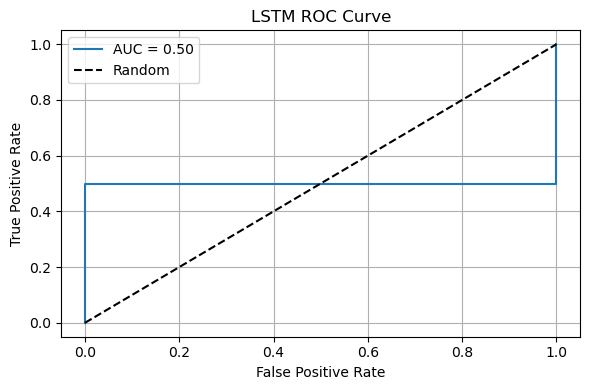

In [21]:
# Evaluate with full metrics
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predict
y_pred_probs = model.predict(X_test).ravel()
y_pred_class = (y_pred_probs > 0.5).astype(int)

# Metrics
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)
roc_auc = roc_auc_score(y_test, y_pred_probs)

print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")
print(f"ROC AUC:   {roc_auc:.2f}")

# Plot ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
# === Layer 3–4 Diagnostics ===

# Agreement between Isolation Forest and Decision Tree
from sklearn.metrics import confusion_matrix

agreement_matrix = confusion_matrix(df['is_anomaly'], df['tree_pred'])
print("Confusion Matrix (IF label vs. Tree prediction):")
print(agreement_matrix)

# Count of flagged trades
total_flagged = df['is_anomaly'].sum()
print(f"Total trades flagged by Isolation Forest: {total_flagged}")

# Count where both agreed
agreed_both = ((df['is_anomaly']) & (df['tree_pred'] == 1)).sum()
print(f"Anomalies confirmed by both IF and Tree: {agreed_both}")

# Count where Tree caught what IF missed
tree_override = ((~df['is_anomaly']) & (df['tree_pred'] == 1)).sum()
print(f"Tree overrides (flagged by Tree only): {tree_override}")

# Count where IF flagged but Tree did not
tree_misses = ((df['is_anomaly']) & (df['tree_pred'] == 0)).sum()
print(f"Tree misses (flagged by IF only): {tree_misses}")


Confusion Matrix (IF label vs. Tree prediction):
[[1004    0]
 [   4   22]]
Total trades flagged by Isolation Forest: 26
Anomalies confirmed by both IF and Tree: 22
Tree overrides (flagged by Tree only): 0
Tree misses (flagged by IF only): 4
